In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
 accuracy_score, precision_score, recall_score, f1_score,
 confusion_matrix, classification_report, roc_curve, roc_auc_score
)
%matplotlib inline
sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

In [3]:
#Load the dataset and inspect its shape, columns, and data types
df = pd.read_csv('titanic.csv')
print('Shape:', df.shape)
df.head()

Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [5]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
#Check for missing values in every column.
df.isnull().sum().sort_values(ascending=False)

Cabin          687
Age            177
Embarked         2
PassengerId      0
Name             0
Pclass           0
Survived         0
Sex              0
Parch            0
SibSp            0
Fare             0
Ticket           0
dtype: int64

C:\Users\PC\AppData\Local\Temp\ipykernel_16648\1660038440.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived', data=df, palette=['#C0392B', '#2E86C1'])


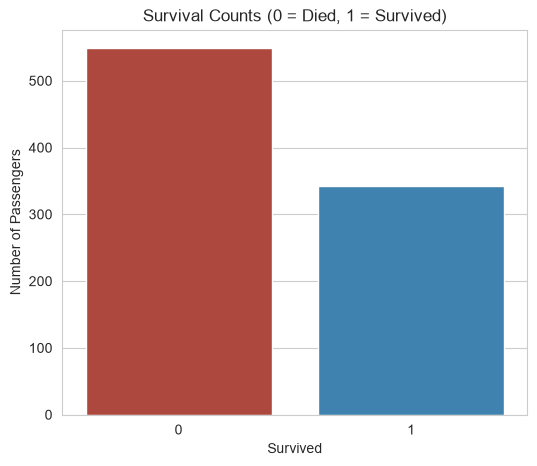

Survived
0    0.616
1    0.384
Name: proportion, dtype: float64


In [7]:
#Visualize the target variable: how many passengers survived vs. didn't?
plt.figure(figsize=(6, 5))
sns.countplot(x='Survived', data=df, palette=['#C0392B', '#2E86C1'])
plt.title('Survival Counts (0 = Died, 1 = Survived)')
plt.xlabel('Survived')
plt.ylabel('Number of Passengers')
plt.show()
print(df['Survived'].value_counts(normalize=True).round(3))

C:\Users\PC\AppData\Local\Temp\ipykernel_16648\2502594962.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sex', y='Survived', data=df, ax=axes[0], palette='Set2')
C:\Users\PC\AppData\Local\Temp\ipykernel_16648\2502594962.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Pclass', y='Survived', data=df, ax=axes[1], palette='Set2')


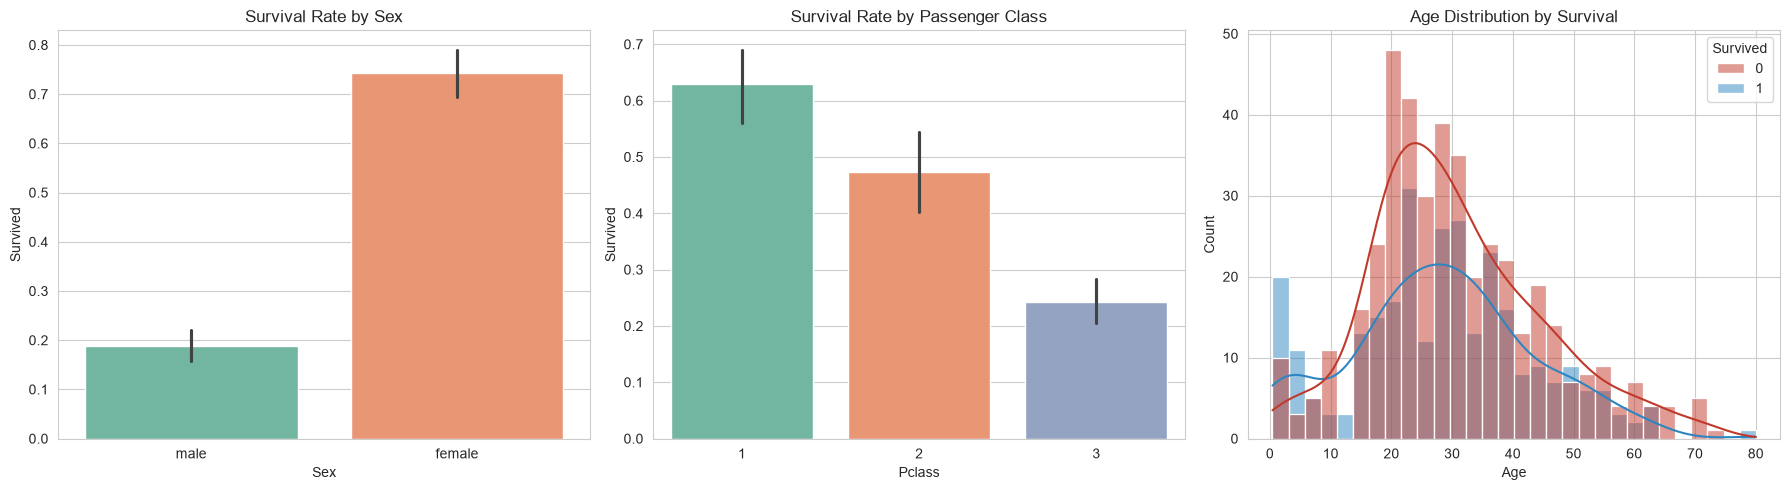

In [8]:
#Explore how survival relates to Sex, Pclass, and Age
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.barplot(x='Sex', y='Survived', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Survival Rate by Sex')
sns.barplot(x='Pclass', y='Survived', data=df, ax=axes[1], palette='Set2')
axes[1].set_title('Survival Rate by Passenger Class')
sns.histplot(data=df, x='Age', hue='Survived', bins=30, kde=True, ax=axes[2], 
palette=['#C0392B', '#2E86C1'])
axes[2].set_title('Age Distribution by Survival')
plt.tight_layout()
plt.show()

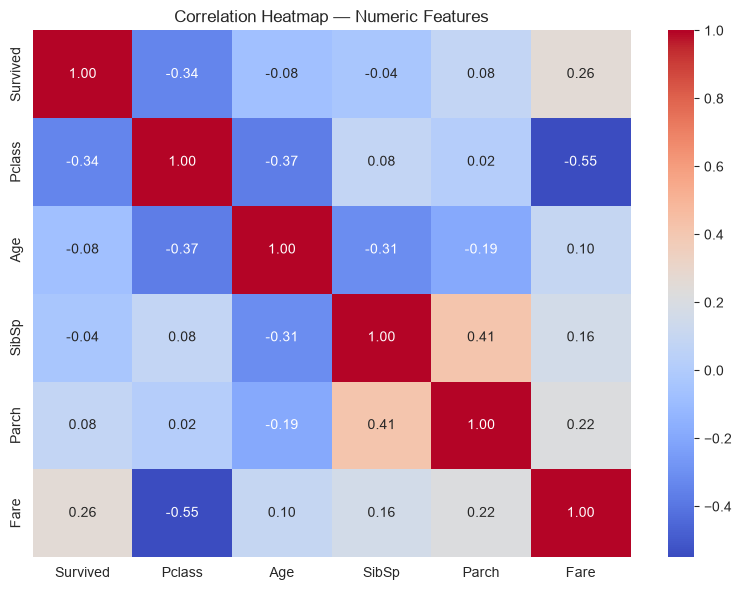

In [9]:
#Correlation heatmap of the numeric features.
plt.figure(figsize=(8, 6))
numeric_df = df[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']]
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap — Numeric Features')
plt.tight_layout()
plt.show()

In [10]:
#Fill missing Age values with the median age, and missing Embarked values with the most common port.
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
print('Remaining missing Age:', df['Age'].isnull().sum())
print('Remaining missing Embarked:', df['Embarked'].isnull().sum())

Remaining missing Age: 0
Remaining missing Embarked: 0


In [11]:
#Engineer a FamilySize feature from SibSp (siblings/spouses) and Parch(parents/children)
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df[['SibSp', 'Parch', 'FamilySize']].head()

,SibSp,Parch,FamilySize
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1


In [12]:
#Drop columns that aren't useful for a numeric classification model: PassengerId, Name, Ticket, and Cabin (too many missing values).
df = df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)
df.columns.tolist()

['Survived',
 'Pclass',
 'Sex',
 'Age',
 'SibSp',
 'Parch',
 'Fare',
 'Embarked',
 'FamilySize']

In [13]:
#Encode the categorical columns (Sex, Embarked) into numbers models can use.
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,7.2500,2,False,True
1,1,1,1,38.0,1,0,71.2833,2,False,False
2,1,3,1,26.0,0,0,7.9250,1,False,True
3,1,1,1,35.0,1,0,53.1000,2,False,True
4,0,3,0,35.0,0,0,8.0500,1,False,True


In [14]:
#Separate features (X) from the target (y), then split into training and test sets (80/20).
X = df.drop('Survived', axis=1)
y = df['Survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
random_state=42, stratify=y)
print('Train shape:', X_train.shape, ' Test shape:', X_test.shape)

Train shape: (712, 9)  Test shape: (179, 9)


In [15]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [16]:
#Logistic Regression.
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)
y_pred_log = log_reg.predict(X_test_scaled)
print('Logistic Regression trained.')

Logistic Regression trained.


In [17]:
#Decision Tree.
dec_tree = DecisionTreeClassifier(max_depth=5, random_state=42)
dec_tree.fit(X_train, y_train)
y_pred_tree = dec_tree.predict(X_test)
print('Decision Tree trained.')

Decision Tree trained.


In [18]:
#Random Forest.
rand_forest = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
rand_forest.fit(X_train, y_train)
y_pred_rf = rand_forest.predict(X_test)
print('Random Forest trained.')

Random Forest trained.


In [19]:
#K-Nearest Neighbors (K=5).
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

In [20]:
#Support Vector Machine (RBF kernel).
svm = SVC(kernel='rbf', probability=True, random_state=42)
svm.fit(X_train_scaled, y_train)
y_pred_svm = svm.predict(X_test_scaled)
print('SVM trained.')

C:\Users\PC\Downloads\minicinda\envs\ml_env\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


SVM trained.


In [21]:
#Write a small helper function that computes all four standard metrics for any model's predictions.
def evaluate(name, y_true, y_pred):
 return {
 'Model': name,
 'Accuracy': accuracy_score(y_true, y_pred),
 'Precision': precision_score(y_true, y_pred),
 'Recall': recall_score(y_true, y_pred),
 'F1-Score': f1_score(y_true, y_pred)
 }
results = [
 evaluate('Logistic Regression', y_test, y_pred_log),
 evaluate('Decision Tree', y_test, y_pred_tree),
 evaluate('Random Forest', y_test, y_pred_rf),
 evaluate('KNN', y_test, y_pred_knn),
 evaluate('SVM', y_test, y_pred_svm),
]
results_df = pd.DataFrame(results).sort_values('F1-Score', 
ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1-Score
0,KNN,0.815642,0.790323,0.710145,0.748092
1,Logistic Regression,0.804469,0.793103,0.666667,0.724409
2,Random Forest,0.810056,0.857143,0.608696,0.711864
3,SVM,0.804469,0.826923,0.623188,0.710744
4,Decision Tree,0.759777,0.740741,0.579710,0.650407


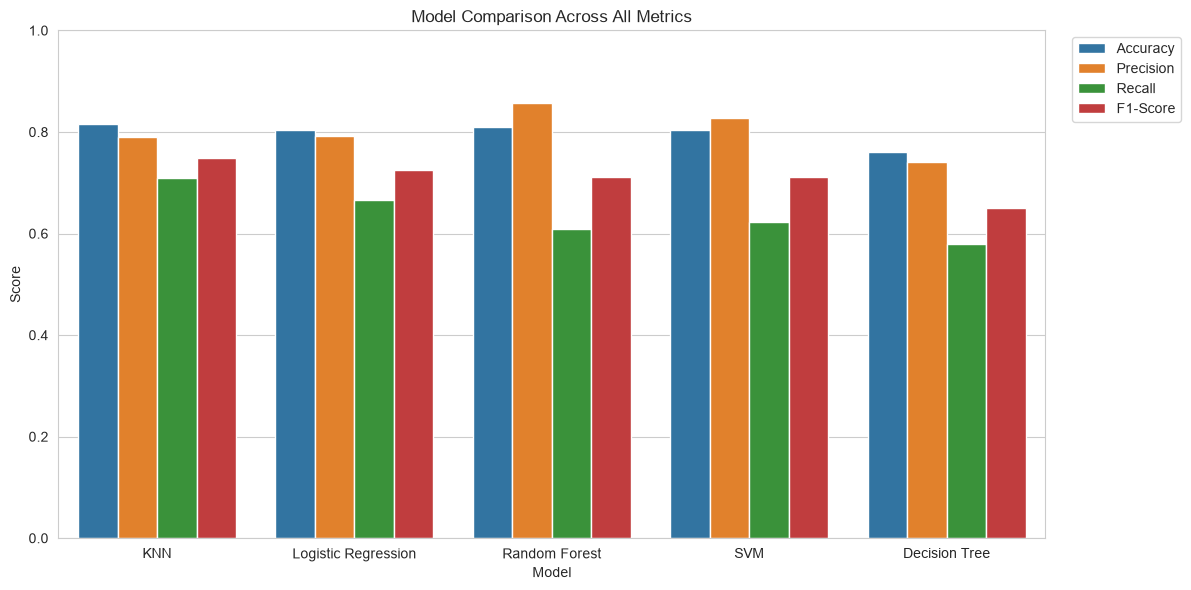

In [22]:
#Plot a bar chart comparing all five models across all four metrics.
results_melted = results_df.melt(id_vars='Model', var_name='Metric', 
value_name='Score')
plt.figure(figsize=(12, 6))
sns.barplot(data=results_melted, x='Model', y='Score', hue='Metric')
plt.title('Model Comparison Across All Metrics')
plt.ylim(0, 1)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

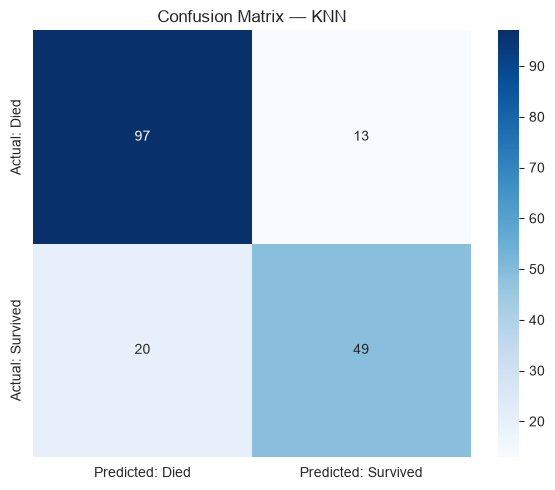

              precision    recall  f1-score   support

        Died       0.83      0.88      0.85       110
    Survived       0.79      0.71      0.75        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.82      0.81       179



In [23]:
#Look more closely at the confusion matrix for the best-performing model.
best_model_name = results_df.iloc[0]['Model']
pred_map = {
 'Logistic Regression': y_pred_log,
 'Decision Tree': y_pred_tree,
 'Random Forest': y_pred_rf,
 'KNN': y_pred_knn,
 'SVM': y_pred_svm
}
best_preds = pred_map[best_model_name]
cm = confusion_matrix(y_test, best_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
 xticklabels=['Predicted: Died', 'Predicted: Survived'],
 yticklabels=['Actual: Died', 'Actual: Survived'])
plt.title(f'Confusion Matrix — {best_model_name}')
plt.tight_layout()
plt.show()
print(classification_report(y_test, best_preds, target_names=['Died', 'Survived']))

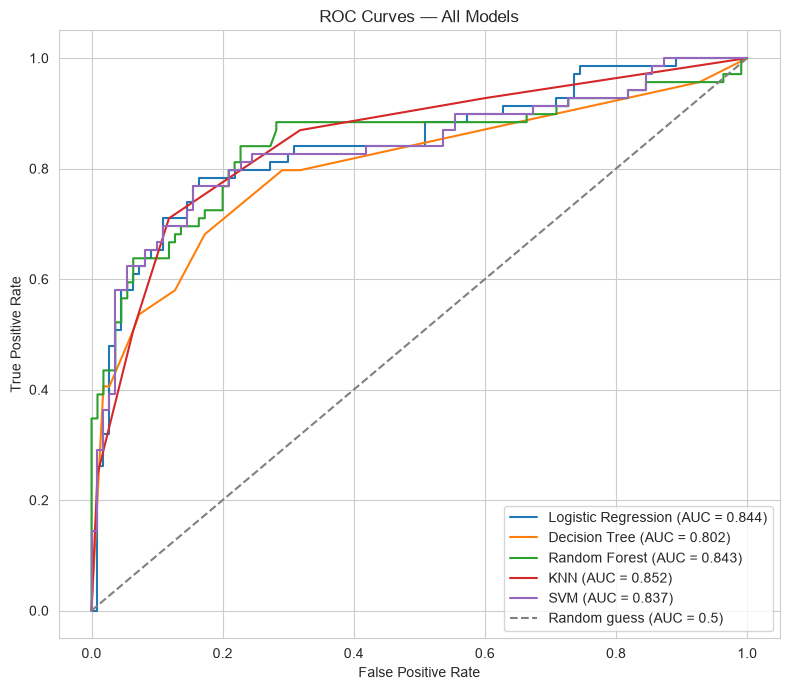

In [25]:
#Plot ROC curves for all five models on one chart, and compare their AUC scores.
proba_map = {
 'Logistic Regression': log_reg.predict_proba(X_test_scaled)[:, 1],
 'Decision Tree': dec_tree.predict_proba(X_test)[:, 1],
 'Random Forest': rand_forest.predict_proba(X_test)[:, 1],
 'KNN': knn.predict_proba(X_test_scaled)[:, 1],
 'SVM': svm.predict_proba(X_test_scaled)[:, 1]
}
plt.figure(figsize=(8, 7))
for name, proba in proba_map.items():
 fpr, tpr, _ = roc_curve(y_test, proba)
 auc = roc_auc_score(y_test, proba)
 plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

C:\Users\PC\AppData\Local\Temp\ipykernel_16648\689882919.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette='viridis')


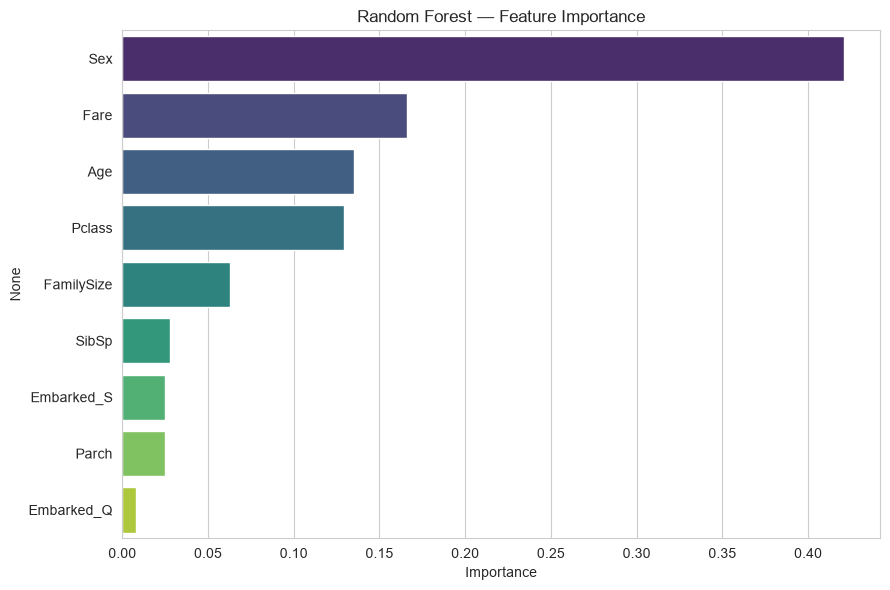

Sex           0.420874
Fare          0.166307
Age           0.134846
Pclass        0.129551
FamilySize    0.062885
SibSp         0.027588
Embarked_S    0.025121
Parch         0.024668
Embarked_Q    0.008161
dtype: float64

In [27]:
#Use the Random Forest's built-in feature importances to see which passenger attributes drove its predictions.
importances = pd.Series(rand_forest.feature_importances_, 
index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(9, 6))
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title('Random Forest — Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()
importances